# Exercise Group - Chapter 4 (Part 01)

Below you find exercises for Chapter 4. The purpose of the prepared code snippets below is to give you some helpful structure for coding by predefining some useful variable names, but you do not need to use these prepared code snippets and prepared variable names if you do not want to. Do not hestitate to use the function `help()` to print the documentation of the functions that you need. If you are stuck, please ask one of the supervisors present.

<br>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import t, pareto, nbinom, norm
from scipy.optimize import minimize

companies = np.loadtxt('../shared_materials/data/DAX_companies.csv', skiprows=1, usecols=[1, 2, 3, 4, 5], delimiter=',')
log_returns = np.diff(np.log(companies), axis=0)

<br>

# Topic 1: Estimating the Linear Correlation and the Rank Correlation of DAX Companies

In the file `DAX_companies.csv` you find a time series of the German stocks [BMW, SAP, Volkswagen, Continental, Siemens] between 03 January 2000 and 11 October 2024. Since both BMW and Volkswagen are German vehicle manufacturers, one could guess that the logarithmic returns of the stocks of both companies exhibit a high correlation. Our goal is therefore to estimate the linear correlation $\rho_L$ and Spearmans's rank correlation $\varrho_S$ between the log-returns $X_{\mathrm{BMW}, i}$ and $X_{\mathrm{VW}, i}$ of BMW and Volkswagen over windows of data.

**Task 1.1**: For each $n \geq 252$, compute the empirical linear correlation estimate $\widehat \varrho_L(X_{\mathrm{BMW}}, X_{\mathrm{VW}})$ based on the previous 252 days, i.e. based on the observations $X_{\mathrm{BMW, n - 251}}, \dots X_{\mathrm{BMW, n}}$. Store all these linear correlation estimates in an array `rho`.
<!--  -->
*Useful Python commands*: `np.cov`

In [2]:
# Get returns
lr_BMW = log_returns[:, 0]
lr_VW = log_returns[:, 2]

print(lr_BMW, lr_VW)

[-0.04118942 -0.01998639 -0.00324969 ...  0.0122509  -0.00728032
 -0.01128473] [-0.04561192  0.00664428  0.02129398 ...  0.01032711 -0.00343054
 -0.00516797]


In [3]:
cov_matrix = np.cov(lr_BMW, lr_VW)

print(cov_matrix[0,0], cov_matrix[0,1], cov_matrix[1,0], cov_matrix[1,1])

0.0004011143662447397 0.00027904710794841603 0.00027904710794841603 0.0005395490483655335


In [4]:
# Set window
td = 252
rho = np.zeros((len(lr_BMW)-td))

In [5]:
# [Ref. p.49] - Estimation of linear and rank correlation

for i in range(len(rho)):
    BMW_w = lr_BMW[i:(i+td)]
    VW_w = lr_VW[i:(i+td)]

    #correlation
    corr_w = np.cov(BMW_w, VW_w)
    BMW_w_var = corr_w[0, 0]
    VW_w_var = corr_w[1, 1]
    cov_w = corr_w[0, 1]
    
    rho[i] = cov_w / np.sqrt(BMW_w_var * VW_w_var)

**Task 1.2**: Write a function `spearman_rho(X1, X2)` that takes two vectors `X1` and `X2` as inputs and returns Spearman's $\varrho$ as in equation (4.2) in the lecture notes,

In [6]:
def spearman_rho(X1, X2):
    n = len(X1)
    scaling_factor = 12/(n*(n**2 - 1))
    mean_diff = (n+1)/2
    
    # Ranks
    rank_X1 = np.argsort(np.argsort(X1)) + 1  # Adding 1 for 1-based ranking --> numpy function? Why not given??
    rank_X2 = np.argsort(np.argsort(X2)) + 1  

    # Center ranks
    rank_X1_centered = rank_X1 - mean_diff
    rank_X2_centered = rank_X2 - mean_diff
    
    sum_product = np.sum(rank_X1_centered * rank_X2_centered)
    
    return scaling_factor * sum_product

**Task 1.3**: For each $n \geq 252$, use your function `spearman_rho` to compute Spearman's $\widehat \varrho_S(X_{\mathrm{BWM}}, X_{\mathrm{VW}})$ based on the previous 252 days, i.e. based on the observations $X_{\mathrm{BMW, n - 251}}, \dots X_{\mathrm{BMW, n}}$. Store all these rank correlation estimates in an array `rho_S`.

In [7]:
# Set parameter
td = 252
rho_S = np.zeros((len(lr_BMW)-td))

In [8]:
for i in range(len(rho_S)):
    rho_S[i] = spearman_rho(lr_BMW[i:(i+td)], lr_VW[i:(i+td)])

**Task 1.4**: Plot the arrays `rho` and `rho_S` over time and interpret your plot.

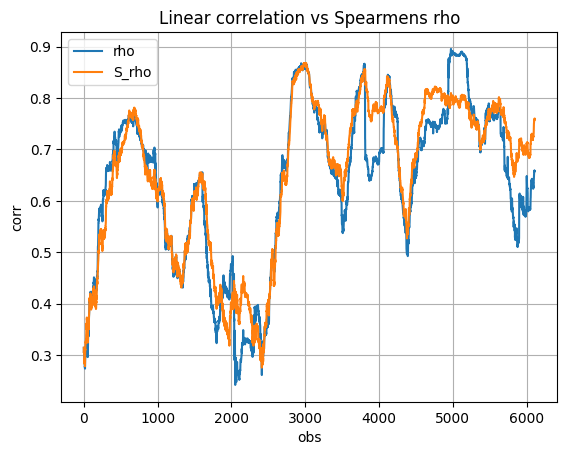

In [9]:
plt.plot(rho, label="rho")
plt.plot(rho_S, label="S_rho")

plt.title("Linear correlation vs Spearmens rho")
plt.xlabel("obs")
plt.ylabel("corr")

plt.legend()
plt.grid()
plt.show()

In [10]:
# Answer:
# Spearmans idea: Work with ranks rather than raw magnigutes --> reduce the impact of outliers and scaling between variables
# And indeed we can see that the rho_S is less sensitve to outliers than the normal rho.

<br>

# Topic 2: Simulating from a Gaussian Copula and a Normal Mixture Copula

Suppose you want to obtain $n \in \mathbb{N}$ samples of a bivariate random vector $U = (U_1, U_2)$ with uniform marginals and a Gaussian copula $G_R^{\mathrm{Ga}}$ for some correlation matrix $R$.

**Task 2.1**: Write a function `sample_Gauss_copula(n, R)` that draws $n$ samples of the copula $G_R^{\mathrm{Ga}}$ with correlation matrix $R$ as in Example 4.36 and returns them as a `numpy` array of shape `(2, n)`.

*Useful Python commands*: `norm.cdf`, The Cholesky decomposition of a a positive semidefinite matrix `R` can be obtained by `np.linalg.cholesky(R)`.

In [11]:
# Set up R-Matrix
def build_corr_matrix(no_rvs, rho):
    return (np.identity(no_rvs) + rho) - np.identity(no_rvs) * rho

In [12]:
R = build_corr_matrix(2, 0.8)
R.shape

(2, 2)

In [13]:
def sample_Gauss_copula(n, R):
    # Step1: Get cholesky decomposition (A)
    A = np.linalg.cholesky(R)

    # Step2: Simulate n-times iid normal observations
    Z = np.random.normal(loc=0, scale=1, size=(2, n)) # --> getting two rv-series essentially

    # Step3: Make Z's dependent on A (dependency strucutre)
    X = np.dot(A, Z)
    
    # Step4: Transform dependent r.v. into univariate scale
    U = norm.cdf(x=X, loc=0, scale=1)
    
    return U

**Task 2.2**: Use your function `sample_Gauss_copula` to generate $n = 10\,000$ samples with cdf $G_R^{\mathrm{Ga}}$, where $R \in \mathbb{R}^{2 \times 2}$ is the correlation matrix with correlation $\varrho_L = 0.8$ and store the samples in an array `samples_rho_pos`. Repeat this procedure for $\varrho_L = -0.8$ and store these samples in an array `samples_rho_neg`. 

In [14]:
# Set parameters
n = 10000
rho_pos = 0.8
rho_neg = -0.8

In [15]:
# Positive Dependency
R = build_corr_matrix(2, rho_pos)
samples_rho_pos = sample_Gauss_copula(n=n, R=R)

print(samples_rho_pos)

[[0.1208154  0.71508387 0.1689877  ... 0.2284712  0.27664318 0.42883954]
 [0.23142839 0.90636187 0.44860068 ... 0.58623628 0.32661224 0.45877587]]


In [16]:
# Negative Dependency
R = build_corr_matrix(2, rho_neg)
samples_rho_neg = sample_Gauss_copula(n=n, R=R)

print(samples_rho_neg)

[[0.80743352 0.03309494 0.66669422 ... 0.64684981 0.09116329 0.30087798]
 [0.50298385 0.97152777 0.06990032 ... 0.19974332 0.82764879 0.67436537]]


**Task 2.3**: Draw a scatter plot that plots the components of the realisations in the array `samples_rho_pos` against each other. In a separate plot, repeat this procedure for the array `samples_rho_neg`.

*Useful Python commands*: `plt.scatter`

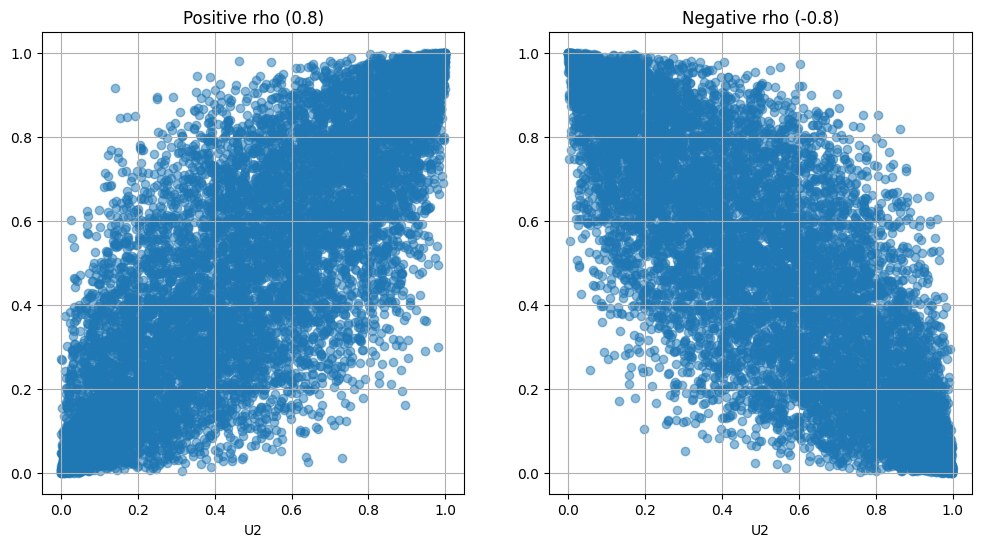

In [17]:
# Subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Positive rho
ax[0].scatter(samples_rho_pos[0, :], samples_rho_pos[1, :], alpha=0.5) #essentially taking both "random assets"
ax[0].set_title("Positive rho (0.8)")
ax[0].set_xlabel("U1")
ax[0].set_xlabel("U2")
ax[0].grid()

# Negative rho
ax[1].scatter(samples_rho_neg[0, :], samples_rho_neg[1, :], alpha=0.5)
ax[1].set_title("Negative rho (-0.8)")
ax[1].set_xlabel("U1")
ax[1].set_xlabel("U2")
ax[1].grid()

plt.show()

In [18]:
# Answer: (What is the essential interpretation)
# We have a portfolio of two assets. We first start to fix the dependency structure via the correlation (obtained by e.g. spearman).
# We then draw iid. random gaussian samples and making them dependent with the dependency structure and transform it into "uniform" space.
# The result shows the dependecy structure of the two assets with each other. So how are the two assets related to each other.

The goal is now to draw samples from a so-called *Normal Mixture Copula*. A normal mixture copula $C_{R_1,\: R_2, \:p}^{\mathrm{Mix}}$ with correlation matrices $R_1 \in \mathbb{R}^{d \times d}$ and $R_2\in \mathbb{R}^{d \times d}$ and mixing probability $p \in (0, 1)$ is defined as $C_{R_1,\: R_2, \:p}^{\mathrm{Mix}} := p C_{R_1}^{\mathrm{Ga}} + (1 - p) C_{R_2}^{\mathrm{Ga}}$. To draw a realisation $u$ from such a normal mixture copula one can apply the following procedure:

1) Draw a realisation $x$ of a Bernoulli-distributed random variable $X$ with parameter $p$.
2) If $x = 1$, set $u = (u_1, \dots, u_d)$ to be realisation of the $C_{R_1}^{\mathrm{Ga}}$ copula.
3) If $x = 0$, set $u = (u_1, \dots, u_d)$ to be realisation of the $C_{R_2}^{\mathrm{Ga}}$ copula.
   
**Task 2.4**: Draw $n = 10\,000$ independent samples from the $C_{R_1,\: R_2, \:p}^{\mathrm{Mix}}$ copula with $p = 0.75$, where $R_1$ is the correlation matrix with correlation $0.8$ and $R_2$ is the correlation matrix with correlation $-0.8$. Store your samples in an array `samples_mix`.

*Useful Python commands*: A sample of $n$ Bernoulli-distributed random variables with parameter $p$ can be obtained by `np.random.binomial(n=1, p=p, size=n)`.

In [33]:
# Set parameters
n=1
p=0.75
size=10000

rho_pos = 0.8
rho_neg = -0.8

In [34]:
# Get dependencies
R1 = build_corr_matrix(2, rho_pos)
R2 = build_corr_matrix(2, rho_neg)

In [35]:
# Get bin sample
bin_sample = np.random.binomial(n=1, p=p, size=size)
sum(bin_sample)

np.int64(7463)

In [48]:
samples_mix = np.zeros((2, size))

for i in range(len(bin_sample)):
    if bin_sample[i] == 1:
        samples_mix[:, :i+1] = p*sample_Gauss_copula(n=n, R=R1)
    
    else: 
        samples_mix[:, i+1] = (1-p)*sample_Gauss_copula(n=n, R=R2)

print(samples_mix[:, :5])

# adapt formula

ValueError: could not broadcast input array from shape (2,1) into shape (2,)

**Task 2.5**: Draw a scatter plot that plots the components of the realisations from the normal mixture copula in the array `samples_mix` against each other. Compare your result to the results of Task 2.3. In which situation has the use of a normal mixture copula an advantage over the use of a Gaussian copula?

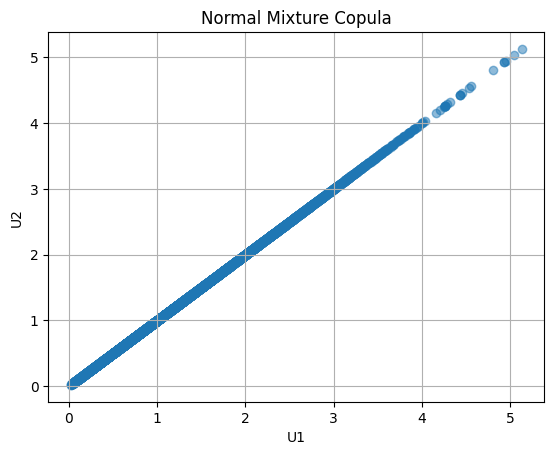

In [51]:
# Subplots
fig = plt.plot(figsize=(12, 6))
plt.scatter(samples_mix[0, :], samples_mix[1, :], alpha=0.5)

plt.title("Normal Mixture Copula")
plt.xlabel("U1")
plt.ylabel("U2")

plt.grid()
plt.show()

In [ ]:
# Answer:
# Account for differnt times --> like clusters?

<br>

# Topic 3: Estimating the Value-at-Risk of an Insurance Portfolio using Copulas

Suppose you work for an insurance company that has to pay for a random number $N$ of claims that occur during the time span of one year. You want to model the average claim size $S$ with a $\mathrm{Par}(5)$ distribution, a Pareto distribution with parameter 5 (in thousands of Euro). Moreover, you suppose that the number $N$ of claims per year follows a $\mathrm{NB}(5, 0.01)$ distribution, i.e. a negative binomial distribution with parameters $n = 5$ and $p = 0.01$. The total claim amount $X$ during the time span of one year is therefore modelled by the random variable $X = N \cdot S$. During normal periods, you would expect that the average claim sizes $S$ are of moderate size and roughly independent of the number $N$ of claims. However, during periods of stress you expect that both the number and the average size of the claims are large. Therefore, you want to model the joint distribution of the random vector $(N, S)$ by a copula that allows for a large upper tail dependence and a small lower tail dependence. Ultimately, you would like to obtain an estimate of the 99.5%-Value-at-Risk of the distribution of the total claim amount $X$ using Monte Carlo simulation.

The idea now is to model the dependence structure of $(N, S)$ by a *reverse Clayton copula* (A random vector $U = (U_1, U_2)$ is said to be distributed according to the reverse Clayton copula $C_\vartheta^{\mathrm{rCl}}$ if the vector $\widetilde{U} = (1 - U_1, 1 - U_2)$ has a Clayton copula $C_\vartheta^{\mathrm{Cl}}$ for some $\vartheta > 0$). Why does this achieve the desired tail dependence?

<details>
  <summary>Answer:</summary>
    
As Example 4.30 shows, the Clayton copula has a lower tail dependence coefficient of $\lambda_\ell = 2^{-1/\vartheta}$ but an upper tail dependence coefficient of $\lambda_u = 0$. Accordingly, the reverse Clayton copula has a lower tail dependence coefficient of 0 and a nonzero upper tail dependence coefficient. This is exactly what the insurance company is trying to model: If $S$ is large, $N$ likewise tends to be large using the reverse Clayton copula while if $S$ and $N$ are low, they behave roughly as if they were independent.

</details>

<br>

**Task 3.1**: Simulate $n = 10\,000$ independent realisations of a Clayton copula $C_\vartheta^{\mathrm{Cl}}$ (with uniform marginals) with $\vartheta = 10$ as in Example 4.45. Use the `numpy` seed 20 for reproducibility. Store these realisations in an array `U_tilde`. 

*Useful Python commands*: `np.random.gamma`, `np.random.uniform`

In [69]:
np.random.seed(20)

In [70]:
# Set parameters
n = 10000
theta = 10

# Gamma dist.
gam_shape = 1/theta
gam_scale = 1 

In [71]:
# Step1: Gamma sample
x = np.random.gamma(shape=gam_shape, scale=gam_scale, size=n)
x

array([4.95152806e-03, 3.17221907e-01, 3.54555674e-15, ...,
       4.27860594e-02, 1.07534344e-05, 4.17496954e-04])

In [81]:
# Step2: Uniform sample
v = np.random.uniform(size=(2, n))
v

array([[0.71036027, 0.05488039, 0.87636509, ..., 0.95622126, 0.27982513,
        0.92169994],
       [0.43069439, 0.75516826, 0.07710623, ..., 0.55792472, 0.01272191,
        0.56559905]])

In [83]:
# Step3: Perform transformation
U_tilde = (-np.log(v)/x + 1)**(-1/theta)
U_tilde

array([[0.6538064 , 0.79314601, 0.04394608, ..., 0.93090126, 0.31092194,
        0.5898055 ],
       [0.59795678, 0.93856324, 0.03266637, ..., 0.76462904, 0.27489185,
        0.48579826]])

**Task 3.2**: Define an array `U` that transforms the array `U_tilde` in a suitable sense so that `U` contains realisations of random vectors that follow a bivariate reverse Clayton copula $C_\vartheta^{\mathrm{rCl}}$ with $\vartheta = 10$. Draw a scatter plot that plots the components of these random vectors against each other.

*Useful Python commands*: `plt.scatter`

In [100]:
# Step4: Get Reverse of Clayton copula?!
U = 1 - U_tilde

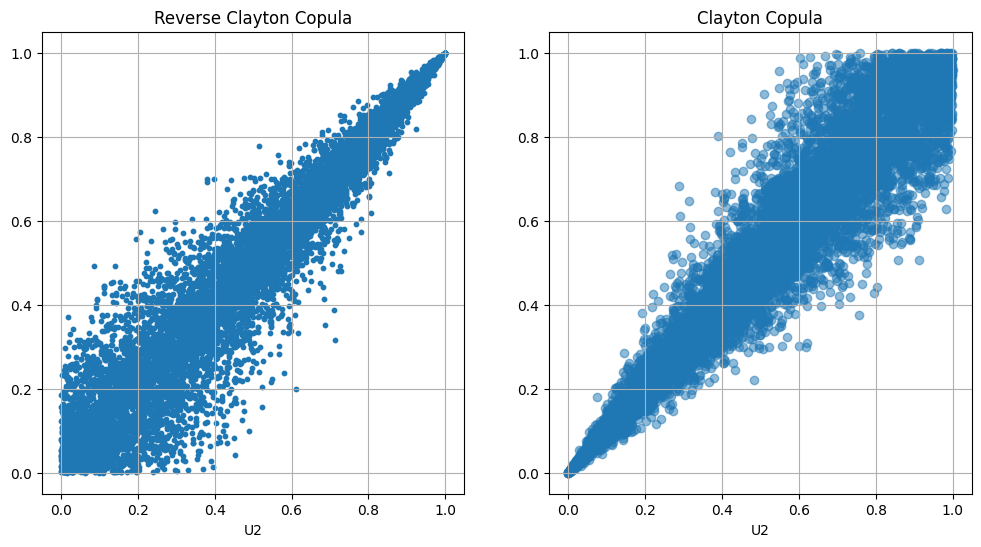

In [110]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Reverse Clayton
ax[0].scatter(U[0], U[1], s=10) #essentially taking both "random assets"
ax[0].set_title("Reverse Clayton Copula")
ax[0].set_xlabel("U1")
ax[0].set_xlabel("U2")
ax[0].grid()

# "Normal" Clayton
ax[1].scatter(U_tilde[0], U_tilde[1], alpha=0.5)
ax[1].set_title("Clayton Copula")
ax[1].set_xlabel("U1")
ax[1].set_xlabel("U2")
ax[1].grid()

plt.show()

A realisation of the random vector $(N, S)$ with the correct marginals and reverse Clayton copula can now be obtained by setting $N = F_{\mathrm{NB}}^{\leftarrow}(U_1)$ as well as $S = F_{\mathrm{Par}}^{-1}(U_2)$, where $F_{\mathrm{NB}}^{\leftarrow}$ and $ F_{\mathrm{Par}}^{-1}$ denote the quantile functions of the $\mathrm{NB}(5, 0.01)$ distribution and of the $\mathrm{Par}(5)$ distribution, respectively.

**Task 3.3**: Define arrays `N` and `S` that contain these (dependent) samples of the random vector $(N, S)$ by transforming the components of the array `U` in the above way.

*Useful Python commands*: The quantiles $F_{\mathrm{NB}}^{\leftarrow}(q)$ and $ F_{\mathrm{Par}}^{-1}(q)$ can be accessed via the `scipy` commands `pareto(b=5).ppf(q)` and `nbinom(n=5, p=0.01).ppf(q)`, respectively.

In [112]:
# Getting dependent samples of N and S -- with Clayton dependency strucuture
N = nbinom(n=5, p=0.01).ppf(U[0])
S = pareto(b=5).ppf(U[1])

print(N, S)
# swap the N and S

[383. 309. 929. ... 213. 576. 415.] [1.10832222 1.01276175 1.98234769 ... 1.0551394  1.29469547 1.15533734]


**Task 3.4** Now, define two arrays `N_indep` and `S_indep` that contain $n = 10\,000$ independent samples of the marginal distributions of $N$ and $S$. Use the `numpy` seed 20 for reproducibility. In two separate plot windows, plot respectively the arrays `N` and `S` as well as the arrays `N_indep` and `S_indep` next to each other and interpret your result.

*Useful Python commands*: `pareto(b=...).rvs(size=...)`, `nbinom(n=..., p=...).rvs(size=...)`, `plt.scatter`

In [113]:
np.random.seed(20)
n = 10000

N_indep = nbinom(n=5, p=0.01).rvs(size=n)
S_indep = pareto(b=5).rvs(size=n)

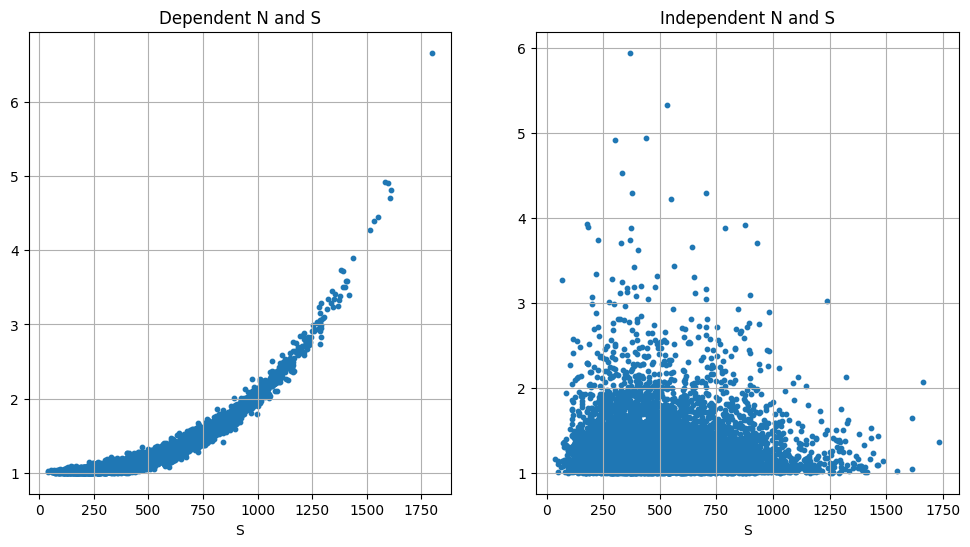

In [116]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Dependent N and S
ax[0].scatter(N, S, s=10)
ax[0].set_title("Dependent N and S")
ax[0].set_xlabel("N")
ax[0].set_xlabel("S")
ax[0].grid()

# Independent N and S
ax[1].scatter(N_indep, S_indep, s=10) #essentially taking both "random assets"
ax[1].set_title("Independent N and S")
ax[1].set_xlabel("N")
ax[1].set_xlabel("S")
ax[1].grid()

plt.show()

In [ ]:
# Answer:
# Clayton copula: Monotonic behavior --> dependency behaviour
# iid: No monotonic behaviour
# --> our copula does make sense

**Task 3.5**: Define two arrays `X` and `X_indep`. The array `X` should contain samples of the total claim amount $X = N \cdot S$ using the samples `N` and `S` with the Clayton dependence structure. The array `X_indep` should contain samples of the total claim amount $X = N \cdot S$ using the independent samples `N_indep` and `S_indep` from the marginals.

In [128]:
# Essentially getting the cdfs (marginals and copula)
X = N * S
X_indep = N_indep * S_indep
print(X, X_indep)

[ 424.48741178  312.94338171 1841.60100736 ...  224.74469318  745.74458873
  479.46499468] [2225.56658826  508.52326542  442.69354783 ... 1525.55140007  364.5937212
  538.2874126 ]


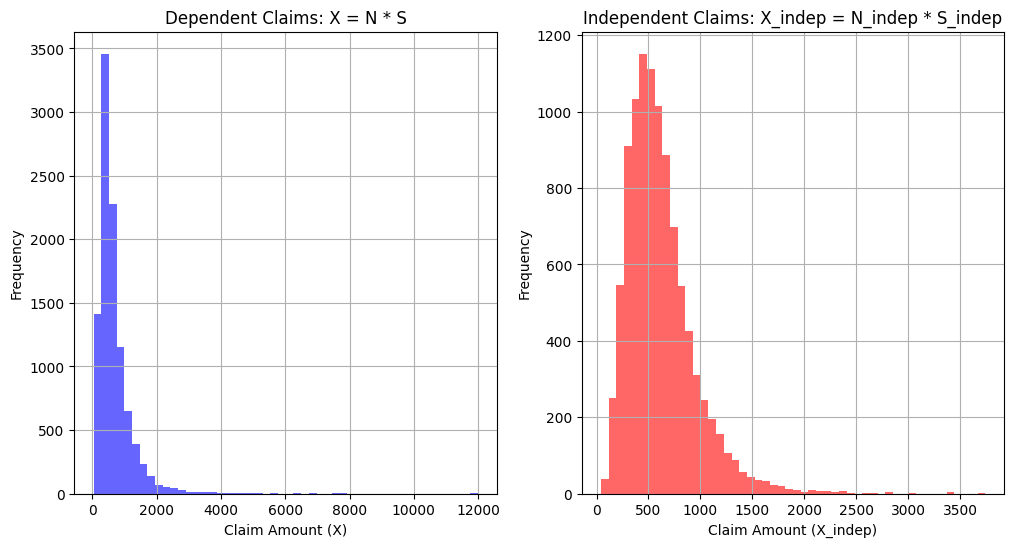

In [129]:
plt.figure(figsize=(12, 6))

# Dependent claims (X)
plt.subplot(1, 2, 1)
plt.hist(X, bins=50, color='blue', alpha=0.6)
plt.title('Dependent Claims: X = N * S')
plt.xlabel('Claim Amount (X)')
plt.ylabel('Frequency')
plt.grid()

# Independent claims (X_indep)
plt.subplot(1, 2, 2)
plt.hist(X_indep, bins=50, color='red', alpha=0.6)
plt.title('Independent Claims: X_indep = N_indep * S_indep')
plt.xlabel('Claim Amount (X_indep)')
plt.ylabel('Frequency')
plt.grid()

plt.show()

**Task 3.6**: Compute the Monte Carlo estimate of the 99.5%-VaR, i.e. the empirical 0.995-quantile, of the distribution of $X$, once in the case where you modeled $N$ and $S$ with upper tail dependence and once in the case where you modeled $N$ and $S$ as independent.

*Useful Python commands*: `np.quantile`

In [127]:

VaR_Clayton = np.quantile(a=X, q=0.95)
VaR_indep = np.quantile(a=X_indep, q=0.95)

print('99.5%-VaR for the total claim amount with upper tail dependence: {:.4f} Mio. Euro. 99.5%-VaR for the total claim amount under independence: {:.4f} Mio. Euro.'.format(VaR_Clayton / 1000, VaR_indep / 1000))

99.5%-VaR for the total claim amount with upper tail dependence: 1.6229 Mio. Euro. 99.5%-VaR for the total claim amount under independence: 1.2181 Mio. Euro.
